In [37]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
pd.set_option('display.max_rows', None)

# Import File application_train

In [2]:
!pip install gdown

In [3]:
import gdown

file_id = "1T1TtBaMtDu0wg2iWa1HLbOS4LZG8i4Zl"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "train.csv", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1T1TtBaMtDu0wg2iWa1HLbOS4LZG8i4Zl
From (redirected): https://drive.google.com/uc?id=1T1TtBaMtDu0wg2iWa1HLbOS4LZG8i4Zl&confirm=t&uuid=2c1c3f11-2f30-4233-bbfb-b73c4c3944bc
To: /content/train.csv
100%|██████████| 166M/166M [00:02<00:00, 79.4MB/s]


'train.csv'

In [4]:
train_df = pd.read_csv("train.csv")
train_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


#application_train

## Data Understanding

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [6]:
# melihat nama kolom satu per satu
train_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [7]:
# Jumlah data dan kolom
train_df.shape

(307511, 122)

## Data Quality Check

In [7]:
# Cek data duplikat full row
train_df.duplicated().sum()


np.int64(0)

In [8]:
# Cek data duplikat berdasarkan ID(SK_ID_CURR)
train_df.duplicated(subset='SK_ID_CURR').sum()

np.int64(0)

In [9]:
# Cek missing value
train_df.isnull().sum()/len(train_df)*100

,0
SK_ID_CURR,0.000000
TARGET,0.000000
NAME_CONTRACT_TYPE,0.000000
CODE_GENDER,0.000000
FLAG_OWN_CAR,0.000000
FLAG_OWN_REALTY,0.000000
CNT_CHILDREN,0.000000
AMT_INCOME_TOTAL,0.000000
AMT_CREDIT,0.000000
AMT_ANNUITY,0.003902


## Handling Missing Value

In [10]:
missing_percentage = train_df.isnull().sum()/len(train_df)*100


In [11]:
# Missing value > 40%
missing_upto_40 = missing_percentage[missing_percentage > 40].index

# Drop column dengan missing value > 40%
train_df = train_df.drop(columns=missing_upto_40)


In [12]:
# Missing value > 0 % dan missing value < 5%
missing_less_5 = missing_percentage[(missing_percentage > 0) & (missing_percentage < 5)].index
train_df = train_df.dropna(subset=missing_less_5)


In [13]:
# Memisahkan kolom numerik dan kategorik yang ada di table
num_coloumns = train_df.select_dtypes(include=np.number).columns
cat_coloumns = train_df.select_dtypes(include=['object']).columns
print(num_coloumns)
print(cat_coloumns)

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE',
       'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL',
       'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_2',
       'EXT_SOURCE_3', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
       'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
       'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3',
       'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6',
       'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMEN

In [14]:
# Input nilai median ke kolom numerik yang missing value < 40% dan >= 5%
for col in num_coloumns:
  train_df[col].fillna(train_df[col].median(), inplace=True)

/tmp/ipython-input-350/1725790930.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].median(), inplace=True)


In [15]:
# Input nilai missing value ('Unknown') ke kolom kategorik (OCCUPATION_TYPE) yang missing value < 40% dan >= 5%
train_df['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)



/tmp/ipython-input-350/240083817.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)


In [16]:
train_df.isnull().sum()/len(train_df)*100

,0
SK_ID_CURR,0.0
TARGET,0.0
NAME_CONTRACT_TYPE,0.0
CODE_GENDER,0.0
FLAG_OWN_CAR,0.0
FLAG_OWN_REALTY,0.0
CNT_CHILDREN,0.0
AMT_INCOME_TOTAL,0.0
AMT_CREDIT,0.0
AMT_ANNUITY,0.0


In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 304531 entries, 0 to 307510
Data columns (total 73 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   304531 non-null  int64  
 1   TARGET                       304531 non-null  int64  
 2   NAME_CONTRACT_TYPE           304531 non-null  object 
 3   CODE_GENDER                  304531 non-null  object 
 4   FLAG_OWN_CAR                 304531 non-null  object 
 5   FLAG_OWN_REALTY              304531 non-null  object 
 6   CNT_CHILDREN                 304531 non-null  int64  
 7   AMT_INCOME_TOTAL             304531 non-null  float64
 8   AMT_CREDIT                   304531 non-null  float64
 9   AMT_ANNUITY                  304531 non-null  float64
 10  AMT_GOODS_PRICE              304531 non-null  float64
 11  NAME_TYPE_SUITE              304531 non-null  object 
 12  NAME_INCOME_TYPE             304531 non-null  object 
 13  NAME

## Mengganti dan Menghapus kolom 'DAYS_BIRTH' dan 'DAYS EMPLOYED' menjadi 'AGE_YEARS' dan 'DAYS_EMPLOYED'

In [19]:
train_df['AGE_YEARS'] = (train_df['DAYS_BIRTH'].abs() / 365).round(0)

train_df['EMPLOYED_YEARS'] = (train_df['DAYS_EMPLOYED'].abs() / 365).round(0)

In [20]:
train_df = train_df.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'])

In [21]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 304531 entries, 0 to 307510
Data columns (total 73 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   304531 non-null  int64  
 1   TARGET                       304531 non-null  int64  
 2   NAME_CONTRACT_TYPE           304531 non-null  object 
 3   CODE_GENDER                  304531 non-null  object 
 4   FLAG_OWN_CAR                 304531 non-null  object 
 5   FLAG_OWN_REALTY              304531 non-null  object 
 6   CNT_CHILDREN                 304531 non-null  int64  
 7   AMT_INCOME_TOTAL             304531 non-null  float64
 8   AMT_CREDIT                   304531 non-null  float64
 9   AMT_ANNUITY                  304531 non-null  float64
 10  AMT_GOODS_PRICE              304531 non-null  float64
 11  NAME_TYPE_SUITE              304531 non-null  object 
 12  NAME_INCOME_TYPE             304531 non-null  object 
 13  NAME

## EDA dan Data Vizualization

In [24]:
# Mengetahui banyaknya deffault (1) dan tidak deffault (0) setelah handling missing value
train_df['TARGET'].value_counts()

,count
TARGET,
0,279864
1,24667


### Education vs Default Rate

In [22]:
edu_and_deffault = train_df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values(ascending=True)
edu_and_deffault

,TARGET
NAME_EDUCATION_TYPE,
Academic degree,0.018405
Higher education,0.053819
Incomplete higher,0.085012
Secondary / secondary special,0.089633
Lower secondary,0.108971


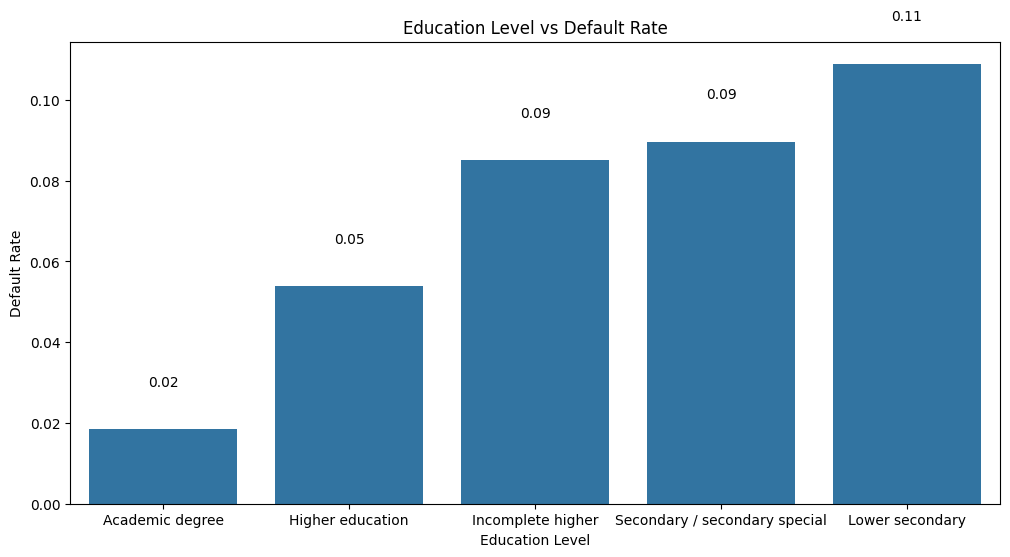

In [23]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=edu_and_deffault.index, y=edu_and_deffault.values)
plt.title('Education Level vs Default Rate')
plt.xlabel('Education Level')
plt.ylabel('Default Rate')
for i, v in enumerate(edu_and_deffault.values):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center', va='bottom')
plt.show()


### Income vs Deffault

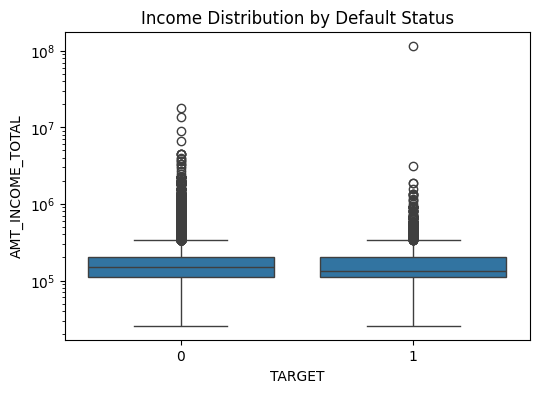

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=train_df)
plt.yscale('log')
plt.title("Income Distribution by Default Status")
plt.show()

## Feature Encoding

In [26]:
cat_columns = train_df.select_dtypes(include=['object']).columns

binary_coloumns = []
multi_coloumns = []

for col in cat_columns:
    if train_df[col].nunique() <= 2:
        binary_coloumns.append(col)
    else:
        multi_coloumns.append(col)

# Label Encoding untuk biner
le = LabelEncoder()
for col in binary_coloumns:
    train_df[col] = le.fit_transform(train_df[col])

# One Hot Encoding untuk multi kategori
train_df = pd.get_dummies(train_df, columns=multi_coloumns)

In [27]:
print(binary_coloumns)
print(multi_coloumns)

['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
['CODE_GENDER', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']


In [28]:
train_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,ORGANIZATION_TYPE_Trade: type 4,ORGANIZATION_TYPE_Trade: type 5,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,ORGANIZATION_TYPE_XNA
0,100002,1,0,0,1,0,202500.0,406597.5,24700.5,351000.0,...,False,False,False,False,False,False,False,False,False,False
1,100003,0,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,...,False,False,False,False,False,False,False,False,False,False
2,100004,0,1,1,1,0,67500.0,135000.0,6750.0,135000.0,...,False,False,False,False,False,False,False,False,False,False
3,100006,0,0,0,1,0,135000.0,312682.5,29686.5,297000.0,...,False,False,False,False,False,False,False,False,False,False
4,100007,0,0,0,1,0,121500.0,513000.0,21865.5,513000.0,...,False,False,False,False,False,False,False,False,False,False


## Classification Modeling

In [29]:
train_df.columns = train_df.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)


In [30]:
# Split data
feature = train_df.drop(columns=['SK_ID_CURR', 'TARGET'])
target = train_df['TARGET']

feature_train, feature_test, target_train, target_test = train_test_split(
    feature,
    target,
    test_size=0.2,
    random_state=42
)

### Model 1: Logistic Regression


In [31]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(feature_train, target_train)

pred_logreg = logreg.predict(feature_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Model 2: Random Forest

In [32]:
rfc = RandomForestClassifier(class_weight='balanced', random_state=42)
rfc.fit(feature_train, target_train)

pred_rfc = rfc.predict(feature_test)


### Model 3 : LightGBM

In [33]:
!pip install lightgbm

In [34]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(class_weight='balanced', random_state=42)
lgbm.fit(feature_train, target_train)
pred_lgbm = lgbm.predict(feature_test)

[LightGBM] [Info] Number of positive: 19679, number of negative: 223945
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.292394 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2901
[LightGBM] [Info] Number of data points in the train set: 243624, number of used features: 171
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


## Evaluasi Model

In [35]:
print("=== Logistic Regression ===")
print(classification_report(target_test, pred_logreg))

print("=== Random Forest ===")
print(classification_report(target_test, pred_rfc))

print("=== LightGBM ===")
print(classification_report(target_test, pred_lgbm))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.94      0.59      0.73     55919
           1       0.11      0.56      0.18      4988

    accuracy                           0.59     60907
   macro avg       0.52      0.58      0.46     60907
weighted avg       0.87      0.59      0.68     60907

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     55919
           1       1.00      0.00      0.00      4988

    accuracy                           0.92     60907
   macro avg       0.96      0.50      0.48     60907
weighted avg       0.92      0.92      0.88     60907

=== LightGBM ===
              precision    recall  f1-score   support

           0       0.96      0.71      0.81     55919
           1       0.17      0.68      0.27      4988

    accuracy                           0.70     60907
   macro avg       0.57      0.69      0.54     60907
weighte

In [36]:
from sklearn.metrics import roc_auc_score

roc_logreg = roc_auc_score(target_test, logreg.predict_proba(feature_test)[:,1])
roc_rfc    = roc_auc_score(target_test, rfc.predict_proba(feature_test)[:,1])
roc_lgbm   = roc_auc_score(target_test, lgbm.predict_proba(feature_test)[:,1])

print("ROC Logistic:", roc_logreg)
print("ROC Random Forest:", roc_rfc)
print("ROC LightGBM:", roc_lgbm)


ROC Logistic: 0.6110273770230119
ROC Random Forest: 0.7266935450065941
ROC LightGBM: 0.7555181775483966


Model yang dipilih adalah LightGBM karena LightGBM memiliki ROC-AUC tertinggi (0.755) dan recall class default sebesar 68%, sehingga lebih efektif dalam mengidentifikasi calon nasabah berisiko gagal bayar dibandingkan Logistic Regression dan Random Forest.

# application_test

## Import File application_test

In [39]:
url = 'https://drive.google.com/uc?export=download&id=16g8ZvFSWn0HfraJ8eZpG7wO2FDVEeeT4'
test_df = pd.read_csv(url)
test_df.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## Preprocessing

In [40]:
# encoding test
test_df = pd.get_dummies(test_df)

# menyamakan kolom yang ada di application_train
test_df = test_df.reindex(columns=feature.columns, fill_value=0)

## Prediksi

In [43]:
pred_test = lgbm.predict(test_df)
proba_test = lgbm.predict_proba(test_df)[:,1]

## Hasil Prediksi

In [44]:
result = pd.DataFrame({
    'PREDICTED_DEFAULT': pred_test,
    'PROBABILITY_DEFAULT': proba_test
})

result.head()

,PREDICTED_DEFAULT,PROBABILITY_DEFAULT
0,0,0.456774
1,1,0.678233
2,0,0.289558
3,0,0.298822
4,1,0.821143


In [45]:
result['PREDICTED_DEFAULT'].value_counts()

,count
PREDICTED_DEFAULT,
1,24679
0,24065


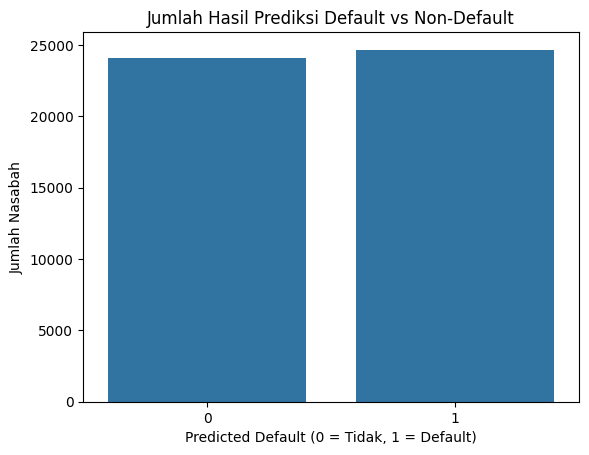

In [46]:
sns.countplot(x='PREDICTED_DEFAULT', data=result)
plt.title("Jumlah Hasil Prediksi Default vs Non-Default")
plt.xlabel("Predicted Default (0 = Tidak, 1 = Default)")
plt.ylabel("Jumlah Nasabah")
plt.show()

In [47]:
result.to_csv("hasil_prediksi.csv", index=False)